In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

In [35]:
data_root = '/astrum/home/hpchzy/code/data/'
date_base = '20260423'

hostname = 'camd9554n2'
# hostname = 'cgnr6760pn2'
# hostname = 'c920bn3'

kernel = "jacobi2d5p"
# kernel = "tl_f90_cg_calc_w"

iarr = 1024

data_path = os.path.join(data_root, f'{date_base}/{hostname}/output')

freq_dict = {'camd9554n2': 3.1, 'cgnr6760pn2': 2.2, 'c920bn3': 2.9}

# Er Ep Wasserstein

/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p1024n100t_tsc_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p512n100t_papi_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p64n100t_likwid_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p128n100t_cgt_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p64n100t_tsc_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p512n100t_papix6_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p128n100t_papi_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p128n100t_tsc_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p64n100t_cgt_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/jacobi2d5p512n100t_likwid_camd9554n2_filt/
/astrum/home/hpchzy/c

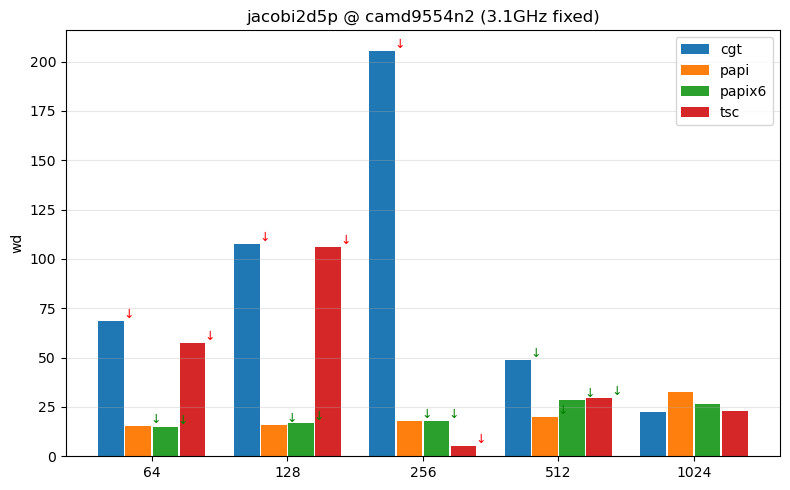

In [41]:
readf = lambda p: float(open(p).read().split()[0])
filt_folders = glob.glob(os.path.join(data_path, f'{kernel}*n*{hostname}_filt/'))

rows = []
for d in filt_folders:
    print(d)
    timer = re.search(f'{kernel}.*n.*_(.*)_{hostname}_filt/', d).group(1)
    if timer == 'likwid':
        continue
    m = pat.search(d)
    if not m or m.group(1) != kernel:
        continue
    try:
        rows.append({
            'iarr': int(m.group(2)), 'timer': m.group(3),
            'wd': readf(os.path.join(d, 'wd.out')),
            'er': readf(os.path.join(d, 'er.out')),
            'ep': readf(os.path.join(d, 'ep.out')),
        })
    except Exception:
        pass

df = pd.DataFrame(rows)
if df.empty:
    print('no data for this kernel')
else:
    iarrs = sorted(df['iarr'].unique())
    ts = sorted(df['timer'].unique(), key=str)
    w = 0.8 / max(len(ts), 1)
    # er_min, ep_min = 0.01, 0.1
    er_min, ep_min = 0.01, 0.1
    arrow_dx = 0.45 * w
    fig, ax = plt.subplots(figsize=(max(8, len(iarrs) * 1.2), 5))
    for ti, t in enumerate(ts):
        x, h, ers, eps = [], [], [], []
        for j, i in enumerate(iarrs):
            r = df[(df['iarr'] == i) & (df['timer'] == t)]
            if r.empty:
                continue
            r = r.iloc[0]
            x.append(j + w * (ti - (len(ts) - 1) / 2))
            h.append(r['wd'])
            ers.append(r['er'])
            eps.append(r['ep'])
        if not x:
            continue
        c = f'C{ti % 10}'
        ax.bar(x, h, width=w * 0.95, label=t, color=c, align='center')
        for xi, hi, e, p in zip(x, h, ers, eps):
            greater_er, greater_ep = e > er_min, p > ep_min
            if not (greater_er or greater_ep):
                continue
            if greater_er and greater_ep:
                color = 'red'
            elif low_ep:
                color = 'blue'
            else:
                color = 'green'
            ax.text(xi + arrow_dx, hi, '↓', ha='left', va='bottom', color=color, fontsize=9, clip_on=False)
    ax.set_xticks(np.arange(len(iarrs)))
    ax.set_xticklabels(iarrs)
    ax.set_ylabel('wd')
    ax.set_title(f'{kernel} @ {hostname} ({freq_dict[hostname]}GHz fixed)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


# Filt

In [8]:
filt_folders = glob.glob(os.path.join(data_path, f'{kernel}{iarr}n*{hostname}_filt/'))

timer_dict = {}

for filt_folder in filt_folders:
    timer = re.search(f'{kernel}{iarr}n.*_(.*)_{hostname}_filt/', filt_folder).group(1)
    print(filt_folder)
    if timer == 'likwid':
        continue
    tr_hist_path = os.path.join(filt_folder, 'tr_hist.csv')
    tr_hist_df = pd.read_csv(tr_hist_path, header=None)
    tr_hist_df.columns = ['ns', 'pr']
    tr_hist_df['ns'] = pd.to_numeric(tr_hist_df['ns'], errors='coerce')
    tr_hist_df['pr'] = pd.to_numeric(tr_hist_df['pr'], errors='coerce')
    tr_hist_df = (
        tr_hist_df.dropna(subset=['ns', 'pr'])
        .loc[lambda d: d['pr'] > 0.0]
        .sort_values('ns', kind='stable')
        .reset_index(drop=True)
    )

    

    tm_path = os.path.join(filt_folder, 'met.csv')
    tm_df = pd.read_csv(tm_path, header=None)
    tm_df.columns = ['ns']
    tm_df['ns'] = pd.to_numeric(tm_df['ns'], errors='coerce')
    tm_df = tm_df.dropna(subset=['ns'])
    
    # 丢弃 top 0.5%（ns > 99.5% 分位点）的样本
    q995 = tm_df['ns'].quantile(0.995)
    tm_df = tm_df.loc[tm_df['ns'] <= q995]
    # 概率统计：按 tr_hist_df 的 bin 数对 tm_df 分箱并对齐
    n_bins = int(len(tr_hist_df))
    if n_bins <= 0:
        tm_hist_df = pd.DataFrame({'ns': [], 'pr': []})
    else:
        edges = np.linspace(tm_df['ns'].min(), tm_df['ns'].max(), n_bins + 1)
        bin_id = pd.cut(tm_df['ns'], bins=edges, include_lowest=True)
        pr = (
            bin_id.value_counts(sort=False)
            .to_numpy(dtype=float)
        )
        pr = pr / pr.sum() if pr.sum() > 0 else pr
        tm_hist_df = pd.DataFrame({
            'ns': tr_hist_df['ns'].to_numpy(),
            'pr': pr,
        })

    

    tm_cdf_df = tm_hist_df.assign(cdf=tm_hist_df['pr'].cumsum())
    tr_cdf_df = tr_hist_df.assign(cdf=tr_hist_df['pr'].cumsum())


    timer_dict[timer] = {
        'tm_cdf_df': tm_cdf_df,
        'tr_cdf_df': tr_cdf_df
    }

    # fig, ax = pyplot.subplots(figsize=(10, 5))
    # ax.plot(tm_cdf_df['ns'], tm_cdf_df['cdf'], label='tm_cdf')
    # ax.plot(tr_cdf_df['ns'], tr_cdf_df['cdf'], label='tr_cdf')
    # ax.set_xlabel('ns')
    # ax.set_ylabel('cdf')
    # ax.set_title(timer)
    # ax.grid(True, alpha=0.3)
    # ax.legend()

    # print(tm_hist_df.head())
    # print(tr_hist_df.tail())


/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/tl_f90_cg_calc_w1024n100t_papi_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/tl_f90_cg_calc_w1024n100t_tsc_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/tl_f90_cg_calc_w1024n100t_cgt_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/tl_f90_cg_calc_w1024n100t_likwid_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260423/camd9554n2/output/tl_f90_cg_calc_w1024n100t_papix6_camd9554n2_filt/


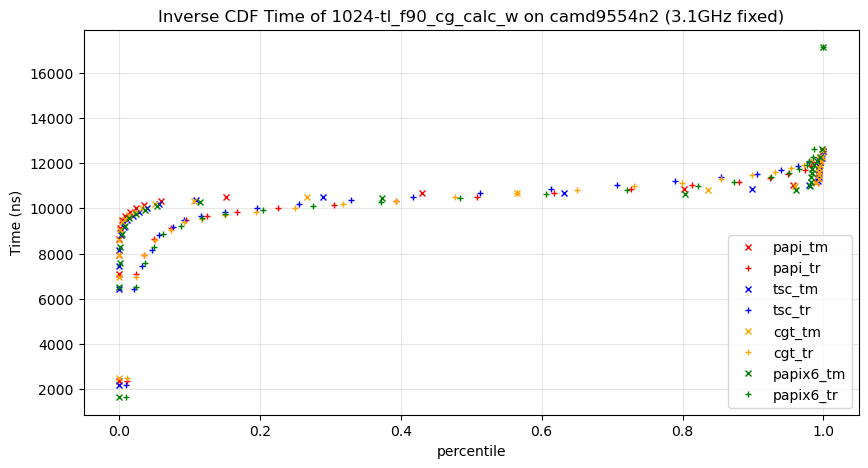

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
color_list = ['red', 'blue', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'lime', 'teal', 'navy', 'maroon', 'gold', 'silver', 'indigo', 'turquoise', 'coral']
for i, timer in enumerate(timer_dict.keys()):
    if timer in ['likwid']:
        continue
    # if timer not in ['tsc']:
    #     continue

    ax.plot(timer_dict[timer]['tm_cdf_df']['cdf'], timer_dict[timer]['tm_cdf_df']['ns'], label=f'{timer}_tm', color=color_list[i], linestyle='None', marker='x', markersize=5)
    ax.plot(timer_dict[timer]['tr_cdf_df']['cdf'], timer_dict[timer]['tr_cdf_df']['ns'], label=f'{timer}_tr', color=color_list[i], linestyle='None', marker='+', markersize=5)

ax.set_xlabel('percentile')
ax.set_ylabel('Time (ns)')
ax.set_title(f'Inverse CDF Time of {iarr}-{kernel} on {hostname} ({freq_dict[hostname]}GHz fixed)')
ax.grid(True, alpha=0.3)

ax.legend()